:::{admonition} Run this notebook yourself!
:class: important

Download the executed notebook: **{nb-download}`deep_nets.ipynb`**!

Run it in your browser: **{binder}`deep_nets.ipynb`**!

:::

(deep_nets)=
# Using Deep Neural Networks with plenoptic

:::{warning}
This notebook requires the optional dependency `torchvision`, which can be installed with `pip`.
:::

Plenoptic is compatible with any model written in pytorch, including deep neural networks. In this notebook we show how to use `plenoptic` with models from the deep network zoos {external+torchvision:ref}`TorchVision <models>` and {external+timm:doc}`timm <models>`, creating a metamer for an intermediate layer of ResNet50.

You may also be interested in [](feather2023), where we create model metamers for several ResNet50 intermediate layers, reproducing some of the results from {cite:alp}`Feather2023-model-metam`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

import plenoptic as po

# this notebook uses torchvision, which is an optional dependency.
# if this import fails, install torchvision in your plenoptic
# environment and restart the notebook kernel.
try:
    import torchvision
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "optional dependency torchvision not found!"
        " please install it in your plenoptic environment "
        "and restart the notebook kernel"
    )


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# so that relative sizes of axes created by po.plot.imshow and others look right
plt.rcParams["figure.dpi"] = 72
# Animation-related settings
plt.rcParams["animation.html"] = "html5"
# use single-threaded ffmpeg for animation writer
plt.rcParams["animation.writer"] = "ffmpeg"
plt.rcParams["animation.ffmpeg_args"] = ["-threads", "1"]

# set seed for reproducibility
po.set_seed(1)

## Prepare model and image for synthesis

In this section, we walk through how to initialize a plenoptic-compatible model using the weights from {external+torchvision:ref}`TorchVision <models>`. Then, at the end of this section, we briefly show to do the same with models from {external+timm:doc}`timm <models>`.

To use one of these deep nets in `plenoptic`, we have to specify three things:
1. The deep net model.
2. The layer(s) to extract.
3. The image pre-processing to use.

### Initialize deep neural network and pre-trained weights

First, we download the model weights for ResNet50 trained on [ImageNet-1K](https://en.wikipedia.org/wiki/ImageNet#ImageNet-1K) and initialize the `torchvision` model.

In [2]:
weights = torchvision.models.ResNet50_Weights.IMAGENET1K_V1
deepnet = torchvision.models.resnet50(weights=weights)

Next, we ensure that our model is in evaluation mode. Many models, including ResNet50, behave differently when in training and evaluation mode. In plenoptic, models are fixed and so we want the evaluation behavior (see [here](remove-grad-doc) for more details):

In [3]:
deepnet.eval();

### Select layer

Next, we specify the layer to target. Figure 2e from {cite:alp}`Feather2023-model-metam` shows an interesting progression for ResNet50 metamers: the layer 2 metamer looks almost like the target image, the layer 3 metamer shows some RGB noise, and the layer 4 metamer is almost completely unidentifiable.

Let's start with `"layer3"`. See [](feather2023) for the other layers, and note that you can specify multiple layers simultaneously.

In [4]:
target_layer = "layer3"

:::{admonition} How do I know what layers I can use?
:class: dropdown hint

You can view possible layer names with {external+torchvision:func}`torchvision.models.feature_extraction.get_graph_node_names`. (For more details on the node naming conventions, please see the {external+torchvision:ref}`About Node Names <about-node-names>` heading in the {external+torchvision:doc}`torchvision documentation <feature_extraction>`.)

```python
from torchvision.models import feature_extraction
# this function returns two lists, the first for training mode, the second for eval mode
feature_extraction.get_graph_node_names(deepnet)[1]
```
:::

### Specify preprocessing

Finally, it is important to specify the preprocessing transform of the model. During neural network training, images are transformed before being passed to the network, and the same transformation needs to be applied when using the trained network. As the [torchvision docs](https://docs.pytorch.org/vision/0.27/models.html#using-the-pre-trained-models) explain it (quoting version `0.27`):

> Before using the pre-trained models, one must preprocess the image (resize with right resolution/interpolation, apply inference transforms, rescale the values etc). There is no standard way to do this as it depends on how a given model was trained. It can vary across model families, variants or even weight versions. Using the correct preprocessing method is critical and failing to do so may lead to decreased accuracy or incorrect outputs.

For models trained on ImageNet, this preprocessing consists of two steps: resizing to a height and width of 224 pixels and normalizing the color channels (subtracting means and dividing by standard deviations). Following {cite:alp}`Feather2023-model-metam`, we recommend including the normalization step in the model for metamer synthesis, but handling the image resizing externally.

In torchvision, this preprocessing transform is a single {class}`torch.nn.Module` which we cannot easily subdivide. This module includes resizing, cropping and normalization:

In [5]:
transform = weights.transforms()
print(transform)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Since we cannot grab a subsection of this transform, we instead create a separate normalization transform, using the specified `mean` and `std`:

In [6]:
norm = torchvision.transforms.Normalize(transform.mean, transform.std)

:::{admonition} What happens if the image resizing is included in the plenoptic model?
:class: dropdown hint

If you include the image resizing in the plenoptic model when synthesizing a model metamer, you will clearly see the effect: since the transform crops out the center of the image, the model is completely insensitive to the border, and so it will be unchanged from initialization.

If you're curious, try it out and see! (Just pass `transform` instead of `norm` to {class}`~plenoptic.models.DeepNetFeatures` model in the block below.)

:::

### Prepare the image

Now, let's prepare the image. The input image needs to be an RGB image with a height and width of 224 pixels. It should probably also be like those found in ImageNet: a single object in the center of the frame that belongs to one of the [image classes](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/). We'll use one of the famous [monkey selfies](https://en.wikipedia.org/wiki/Monkey_selfie_copyright_dispute), and resize it appropriately:

In [7]:
img = po.data.macaque()
# here we downsample the original image by a factor of 4 and then lop off the bottom.
# that way, when we take the central 224 pixels in the following block, we end up with a
# decent image.
img = po.process.blur_downsample(img, 2)[..., :-59, :]

As discussed above, models trained on ImageNet should be passed an image of size 224 by 224. We'll use plenoptic's {func}`plenoptic.process.center_crop` to do so, grabbing the required size directly from the model's associated `transform`;

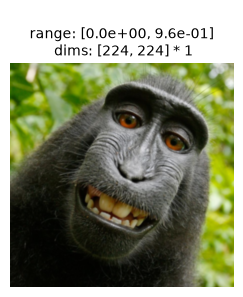

In [8]:
img = po.process.center_crop(img, transform.crop_size[0])
po.plot.imshow(img, as_rgb=True);

### Last steps

Now we can finally create our model by passing the neural network, target layer, and preprocessing transform to plenoptic's {class}`~plenoptic.models.DeepNetFeatures`

In [9]:
model = po.models.DeepNetFeatures(deepnet, target_layer, norm)

Finally, let's remove the gradient from all model parameters (as models in plenoptic [are fixed](remove-grad-doc)), convert everything to float64, for [reproducibility](float64-doc), and move everything to `DEVICE`:

In [10]:
img = img.to(DEVICE).to(torch.float64)
model.to(DEVICE).to(torch.float64)
po.remove_grad(model)

:::{admonition} How to do this with `timm`?
:class: dropdown hint

The syntax for `timm` is slightly different than for `torchvision`, especially with how their transforms are represented, but their models can be used in the same manner. The following block of code will instantiate the same `model` <!-- skip-lint --> and `img`, grabbing ResNet50 and its weights from `timm` instead:

```python
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform
import plenoptic as po

# since these two models are identical, they have the same layer names
target_layer = "layer3"
deepnet = timm.create_model("timm/resnet50.tv_in1k", pretrained=True)
deepnet.eval()
transform = create_transform(
    **resolve_data_config(deepnet.pretrained_cfg, model=deepnet)
)
# timm transforms can be indexed into, so we can sub-select the parts of it we want
norm = transform.transforms[-1]
# note that this line is the same regardless of which model zoo you use
model = po.models.DeepNetFeatures(deepnet, target_layer, norm)
# the only difference for the image is how we crop out the center 224 --
# here we're the crop transform from the model's associated transform directly,
# rather than using plenoptic's center_crop function
img = po.data.macaque()
img = po.process.blur_downsample(img, 2)[..., :-59, :]
crop = transform.transforms[1]
img = crop(img)
```
:::

## Understand the model

### Image classification

ResNet50 is trained to classify images into one of [1000 categories](https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/). Any metamer of an intermediate layer should preserve this classification, which is the output of the final layer; this is one of the criteria that {cite:alp}`Feather2023-model-metam` check for synthesis success. Let's examine that classification now, creating a little helper function:

In [11]:
imagenet_categories = np.asarray(weights.meta["categories"])
# Move deepnet to float64, device since we know our images are all float64
deepnet.to(torch.float64).to(DEVICE)


def get_category(image):
    # Get probabilities of each image category
    image_cat = torch.nn.functional.softmax(deepnet(norm(image)), dim=1)
    # Convert to 1d numpy array, so we can use as index in
    # imagenet_categories above.
    image_cat = po.to_numpy(image_cat.squeeze())
    return imagenet_categories[image_cat.argmax()]


print(f"ResNet50 predicted class: {get_category(img)}")

ResNet50 predicted class: guenon


:::{admonition} How to do this with `timm`?
:class: dropdown hint

`timm` does not store the ImageNet categories along with the model, so we have to retrieve them separately:

```python
import urllib

# Download ImageNet-1k categories as a txt file from torchvision's github
r = urllib.request.urlopen("https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt")
# Convert to a numpy array
imagenet_categories = np.asarray(r.read().decode().split("\n"))
```

After the above, `get_category` can be defined as for `torchvision`.
:::

The category, [guenon](https://en.wikipedia.org/wiki/Guenon), is an Old World monkey. Though it isn't the actual species of the monkey in question (a [Celebes crested macaque](https://en.wikipedia.org/wiki/Celebes_crested_macaque)), it's a reasonable category for it.

After we synthesize the metamer, we will ensure that our model correctly classifies it as a guenon as well.

### Output visualization

Our `model` <!-- skip-lint --> object now returns only the activations from our specified layer as a single 2d vector (with the first dimension corresponding to the batch dimension of our input):

In [12]:
rep = model(img)
print(rep)
print(rep.shape)

tensor([[0.1338, 0.0000, 0.0897,  ..., 0.3310, 0.0000, 0.0000]],
       device='cuda:0', dtype=torch.float64)
torch.Size([1, 200704])


We have flattened the model representation of the given layer (to support representations from multiple layers simultaneously). If you would like to retrieve the original shape, you can use the {func}`~plenoptic.models.DeepNetFeatures.convert_to_dict` method:

In [13]:
rep = model.convert_to_dict(rep)
print(rep.keys())
print(rep[target_layer].shape)

odict_keys(['layer3'])
torch.Size([1, 1024, 14, 14])


{class}`~plenoptic.models.DeepNetFeatures` also has a {func}`~plenoptic.models.DeepNetFeatures.plot_representation` method, which creates two subplots. The first plots the average across channel, the average spatial representation, while the second averages across space to get a per-channel average representation:

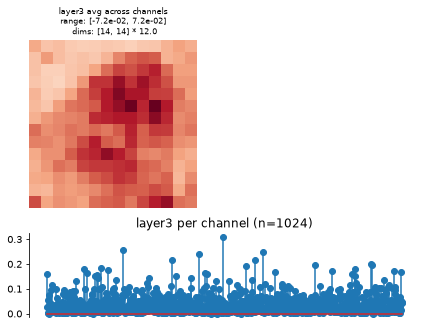

In [14]:
fig, _ = model.plot_representation(rep)

Now that we understand our model, let's synthesize some metamers!

## Synthesize the metamer

Let us initialize our metamer object using the above image and model:

In [15]:
met = po.Metamer(img, model)

We could just call {func}`~plenoptic.Metamer.synthesize` to synthesize the metamer from here, but we have found better results when tweaking the optimization hyperparameters. We can do this using {func}`~plenoptic.Metamer.setup`:

:::{warning}

The hyperparameters shown here are the ones that work best for this deep net, target layer, and image. You will likely need to tweak them for other synthesis problems. It is likely that they make a reasonable starting point, but you are encouraged to experiment!

:::

In [16]:
scheduler = torch.optim.lr_scheduler.StepLR
scheduler_kwargs = {"step_size": 3000, "gamma": 0.5}
met.setup(
    optimizer_kwargs={"amsgrad": False},
    scheduler=scheduler,
    scheduler_kwargs=scheduler_kwargs,
)

In the above:
- We are using one of torch's learning-rate schedulers, {class}`~torch.optim.lr_scheduler.StepLR`, to halve (`gamma`) the learning-rate every 3000 steps (`step_size`).
- We are not changing the optimizer or its learning rate from their default values ({class}`~torch.optim.Adam` and `0.01`, respectively, see {func}`~plenoptic.Metamer.setup` for details on other defaults).
- We are, however, specifying that we do not want to use the AMSGrad variant  of the Adam optimizer, which is plenoptic's default behavior.
- We are also not changing our initial image from the default: random pixels uniformly distributed between 0 and 1.

Now that we've set our optimization hyperparameters, we can synthesize our metamer!

In [17]:
# by setting stop_iters_to_check=max_iter, we ensure it keeps going through
# all iterations
met.synthesize(max_iter=6000, stop_iters_to_check=6000, store_progress=100)

  0%|          | 0/6000 [00:00<?, ?it/s]

:::{admonition} How many iterations?
:class: hint

Here we're only running optimization for 6000 iterations, which is enough to demonstrate the point, but if you were to use these metamers in an experiment, we would recommend running synthesis for longer and thinking carefully about your success criteria, see [](good-enough) and [](feather-synthesis-success) for more discussion.
:::

Let's call {func}`~plenoptic.plot.synthesis_status` to visualize the synthesis status:

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0016976601424805965..1.0000506869582761].


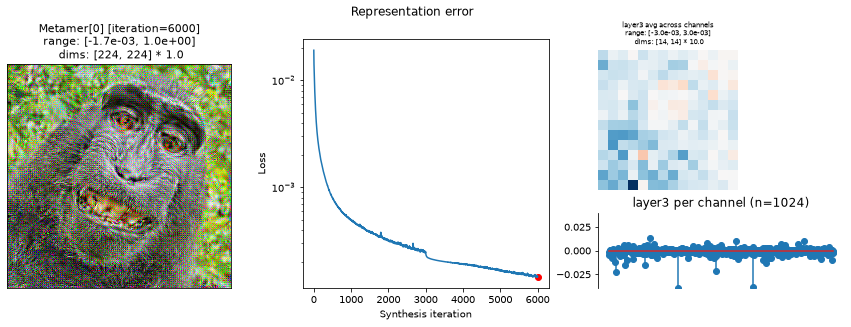

In [18]:
po.plot.synthesis_status(met, figsize=(15, 4.5));

In the above plot, we can see the metamer in the leftmost subplot, the loss over synthesis iterations in the middle, and the representation error on the right:
- Our metamer matches the result discussed earlier in this notebook: as a layer 3 metamer, it looks similar to the original image with some RGB noise added.
- We can see that the optimization performed reasonably well: the loss decreased gradually over synthesis. If you were using these stimuli in an experiment, it would be worth continuing a bit more to get the loss even lower, but this demonstrates the point.
- The representation error plot has the same structure as the {func}`~plenoptic.models.DeepNetFeatures.plot_representation` plot above. We can see that, while there's variation across both channels and space, there's not an obvious outlier whose error we have been unable to constrain.

And we can animate the above figure over synthesis iterations as well, to see the metamer take shape:

In [19]:
po.plot.synthesis_animate(met, figsize=(15, 4.5))

/home/jenkins/agent/workspace/CCN_neurorse_plenoptic_PR-460/lib/python3.12/site-packages/plenoptic/plot/synthesis.py:2074: UserWarning: 60 frames of saved metamer clipped: Clipping input data to the valid range for imshow with RGB data ([0..1] for floats). To avoid clipping, use process_image argument.
  warnings.warn(warning_msg)


Finally, let's ensure that our metamer has the same image category as our initial image:

In [20]:
print(f"Target image category: {get_category(met.image)}")
print(f"Metamer category: {get_category(met.metamer)}")

Target image category: guenon
Metamer category: guenon


In this notebook, we have demonstrated how to use deep neural networks from external models zoos with  {class}`plenoptic.models.DeepNetFeatures`, and shown how to generate metamers for an intermediate layer.